# HealthConnect Clinic — Week 6
## Data Science Track: Model Improvement, Error Analysis & Validation

**Programme:** AnalystLab Africa Experience Lab

**Project:** HealthConnect Clinic Experience Lab

**Project Title:** Improving Patient Appointment Attendance and Healthcare Support Using Data and AI

**Track:** Data Science

**Week:** 6 — HealthConnect Integration, Advanced Development & Validation

**Version:** 1.0

In Week 5, I established a reliable Logistic Regression baseline for predicting appointment no-shows and explicitly stated that the Week 5 objective was a working baseline, not a final model. This Week I'm building forward from that baseline: analysing its weaknesses, refining the feature set where evidence supports it, developing and comparing three additional modelling approaches, validating the results against the intended clinic use case, and completing a mandatory cross-track integration activity.

**Highlighting to the Week 6 brief:**

| Assignment requirement | Section |
|---|---|
| Week 5 → Week 6 transition | 1 |
| Part 1 — Integration readiness | 2|
| Recreating the Week 5 foundation (not repeating it) | 3 |
| Task 1 — Baseline weaknesses | 4 |
| Tasks 2–4 — Error analysis, error sources, false positives/negatives | 5 |
| Task 5–6 — Feature adequacy review and evidence-based refinement | 6 |
| Task 7 — Improved modelling approaches (three additional models) | 7 |
| Tasks 8–9 — Model comparison and evaluation | 8 |
| Task 10 — Business-use-case suitability | 9 |
| Task 11 — Incorporating Data Analytics track findings | 10 |
| Task 12–13 — Final candidate model and modelling decisions | 11 |
| Task 14 — Model limitations and risks | 12 |
| Task 15 — Week 7 testing requirements | 13 |
| Mandatory cross-track integration | 14 |
| Assumptions/limitations/risks/dependencies review | 15 |
| Saving the model-ready dataset and updated data dictionary | 16 |


## 1. Week 5 → Week 6 Transition

| Item | Summary |
|---|---|
| **Main Week 5 output** | A patient-grouped, leakage-checked binary modelling dataset and a Logistic Regression baseline (Accuracy 61.6%, ROC-AUC 0.671), together with five engineered features (`prev_no_show_rate`, `lead_time_band`, `high_prev_no_show`, `long_distance`, `no_reminder`). |
| **Most important result produced** | Confirmation that booking lead time and prior no-show history carry genuine, model-usable signal, and a leakage-safe evaluation protocol (`GroupShuffleSplit` by `patient_id`) that Week 6 continues to rely on. |
| **Main issue/limitation discovered** | Three original variables (`booking_lead_days`, `distance_to_clinic_km`, `previous_no_shows`) were removed for being highly correlated with their engineered counterparts. This decision was justified for the linear baseline, but its effect on non-linear, tree-based candidate models had not yet been tested — flagged directly in the Week 5 recommendations. |
| **Track(s) relevant to Week 6 activity** | Data Analytics, which shared a completed set of Week 6 findings on lead-time, reminder, and no-show-history interactions relevant to modelling decisions. No interaction took place with the Machine Learning Engineering or Project Management tracks this week. |
| **What Week 6 improves, integrates, and validates** | Improving the baseline through error analysis and evidence-based feature refinement; integrating the Data Analytics track's Week 6 findings directly into a feature-refinement decision; validating whether the resulting model is suitable for a real HealthConnect risk-prioritisation use case. |


## 2. Week 6 Integration Readiness

### A. Integration Point

- **Track worked with:** Data Analytics

- **What was received from the Data Analytics track:**  
  Descriptive findings showing how **booking lead time, reminder activity, and previous no-show history** are related to appointment outcomes.

- **What was provided back to the Data Analytics track:**  
  A modelling-based assessment of one of their findings — whether the **combined pattern of lead time and previous no-show history** could be turned into a useful predictive feature.

- **Why this connection is relevant:**  
  The Data Analytics findings were not just reported in the Data Science work. One of the findings was taken forward as a **specific modelling hypothesis and tested using the predictive model**.

### B. Integration Objective

The main objective was to move beyond simply mentioning the Data Analytics findings.

At least one finding was converted into a **concrete feature hypothesis and tested using cross-validation**. The result was then documented, whether the feature improved the model or not.

This provides evidence of actual **cross-track integration** rather than simply referencing another track's findings.

### C. Evidence

The Data Analytics finding, the feature hypothesis it led to, and the cross-validated modelling result are documented in **10 and 14**.

**No interaction occurred with the Machine Learning Engineering or Project Management tracks during Week 6.** 

# 3.0 Recreating the Week 5 Foundation

In Week 5, I completed the main **data preparation and feature engineering** steps required for the HealthConnect no-show prediction model.

In this section, I recreated those steps in a condensed form to rebuild the working objects needed for Week 6, including `X_train`, `X_test`, the fitted baseline pipeline, and the model predictions.

This section does **not introduce new exploratory analysis or new feature-engineering decisions**. It simply reconstructs the foundation I created and validated in Week 5 so that the Week 6 modelling and integration work can continue from the same baseline.

## 3.1 Importing Required Libraries and Loading of Dataset

In [3]:
# Importing the libraries required for recreating the Week 5 pipeline and for the Week 6 model work
import pandas as pd                                  # handling the tabular appointment data
import numpy as np                                    # supporting numeric operations
import matplotlib.pyplot as plt                       # producing the required charts
import seaborn as sns                                  # producing annotated heatmaps
import joblib                                          # saving the finalised model artefact

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Loading the original dataset
df_raw = pd.read_csv("HealthConnect_Appointment_Data.csv")
print(f"Loaded {df_raw.shape[0]} appointment records and {df_raw.shape[1]} columns.")

Loaded 5000 appointment records and 18 columns.


## 3.2 Recreating The Binary Modellling Population 

In [4]:
# Reconstructing the binary modelling population defined in Week 5: excluding Cancelled outcomes
df_processed = df_raw[df_raw["appointment_outcome"].isin(["Attended", "No-Show"])].copy()
df_processed["no_show"] = (df_processed["appointment_outcome"] == "No-Show").astype(int)

# Applying the Week 5 missing-value treatment: an explicit category for reminder_channel,
# and median imputation for the two remaining numeric gaps
df_processed["reminder_channel"] = df_processed["reminder_channel"].fillna("Not Recorded")
df_processed["distance_to_clinic_km"] = df_processed["distance_to_clinic_km"].fillna(
    df_processed["distance_to_clinic_km"].median())
df_processed["waiting_time_minutes"] = df_processed["waiting_time_minutes"].fillna(
    df_processed["waiting_time_minutes"].median())
df_processed = df_processed.drop_duplicates().copy()

# Removing identifiers, the redundant age band, raw dates, the target source column,
# and the leakage-risk waiting-time variable — all decided and justified in Week 5
cols_to_drop = ["appointment_id", "age_group", "booking_date", "appointment_date",
                "appointment_outcome", "waiting_time_minutes"]
df_cleaned = df_processed.drop(columns=cols_to_drop, errors="ignore")

print(f"Modelling population: {len(df_cleaned):,} appointments, {df_cleaned.shape[1]} columns retained.")

Modelling population: 4,737 appointments, 13 columns retained.


In [6]:
# Recreating the five Week 5 engineered features
df_feature = df_cleaned.copy()

# Historical no-show rate, safely handling patients with no appointment history
df_feature["prev_no_show_rate"] = (
    df_feature["previous_no_shows"] / df_feature["previous_appointments"].replace(0, np.nan)
).fillna(0)

# Operational lead-time bands
df_feature["lead_time_band"] = pd.cut(
    df_feature["booking_lead_days"],
    bins=[-0.1, 7, 21, 40, 60],
    labels=["0-7 days", "8-21 days", "22-40 days", "41-60 days"]
)

# High previous no-show flag, long-distance flag, and an explicit no-reminder flag
df_feature["high_prev_no_show"] = (df_feature["previous_no_shows"] >= 2).astype(int)
df_feature["long_distance"] = (
    df_feature["distance_to_clinic_km"] > df_feature["distance_to_clinic_km"].median()).astype(int)
df_feature["no_reminder"] = (df_feature["reminder_sent"] == "No").astype(int)

print("Engineered features recreated:",
      ["prev_no_show_rate", "lead_time_band", "high_prev_no_show", "long_distance", "no_reminder"])

Engineered features recreated: ['prev_no_show_rate', 'lead_time_band', 'high_prev_no_show', 'long_distance', 'no_reminder']


## 3.3 Rebuilding The Week 5 Final Features Set

In [8]:
# Recreating the Week 5 final feature set and the patient-grouped train/test split
NUMERIC_FEATURES = ["age", "previous_appointments", "prev_no_show_rate"]
CATEGORICAL_FEATURES = ["gender", "appointment_type", "appointment_day", "appointment_time",
                         "reminder_sent", "reminder_channel", "lead_time_band"]
BINARY_FEATURES = ["high_prev_no_show", "long_distance", "no_reminder"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES
TARGET = "no_show"

# booking_lead_days, distance_to_clinic_km, and previous_no_shows were dropped in Week 5
# for being highly correlated with their engineered counterparts — that decision is revisited
# with fresh evidence in Section 6, so df_feature retains these columns for now rather than dropping them

df_model = df_feature[ALL_FEATURES + [TARGET] + ["patient_id"]].copy()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(splitter.split(df_model[ALL_FEATURES], df_model[TARGET], groups=df_model["patient_id"]))

X_train = df_model[ALL_FEATURES].iloc[train_idx].copy()
X_test = df_model[ALL_FEATURES].iloc[test_idx].copy()
y_train = df_model[TARGET].iloc[train_idx].copy()
y_test = df_model[TARGET].iloc[test_idx].copy()
groups_train = df_model["patient_id"].iloc[train_idx]

print(f"Training set: {len(X_train):,} appointments | Test set: {len(X_test):,} appointments")
print(f"Patient overlap between sets: "
      f"{len(set(df_model['patient_id'].iloc[train_idx]) & set(df_model['patient_id'].iloc[test_idx]))}")

Training set: 3,771 appointments | Test set: 966 appointments
Patient overlap between sets: 0


## 3.4 Baseline Re-creation For Ease Comparison

In [11]:
# Recreating and refitting the Week 5 baseline pipeline exactly as specified
baseline_preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("scale", StandardScaler())]), NUMERIC_FEATURES),
    ("bin", "passthrough", BINARY_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
])

baseline_pipeline = Pipeline([
    ("preprocess", baseline_preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])

baseline_pipeline.fit(X_train, y_train)
y_pred_base = baseline_pipeline.predict(X_test)
y_proba_base = baseline_pipeline.predict_proba(X_test)[:, 1]

base_acc = accuracy_score(y_test, y_pred_base)
base_auc = roc_auc_score(y_test, y_proba_base)
print(f"Baseline recreated — Test Accuracy: {base_acc:.3f} | Test ROC-AUC: {base_auc:.3f}")
print("(Matches the Week 5 reported values of 61.6% accuracy and 0.671 ROC-AUC.)")

Baseline recreated — Test Accuracy: 0.616 | Test ROC-AUC: 0.671
(Matches the Week 5 reported values of 61.6% accuracy and 0.671 ROC-AUC.)


## Result
The result above comfirmed that the recreated baseline reproduces the Week 5 results exactly (**Accuracy: 61.6%, ROC-AUC: 0.671**). This confirms that I am building the Week 6 analysis from the same validated baseline, rather than from a different or modified version and this also makes it easy to compare the baseline with improved models

## 4. Analysing the Weaknesses of the Week 5 Baseline

I identified three main weaknesses in the Week 5 baseline that I want to address in Week 6:

1. **Modest predictive performance**  
   The model achieved a ROC-AUC of **0.671**, which is better than the 0.500 random-reference level but still shows only modest ability to distinguish between No-Show and Attended appointments. I therefore cannot consider the model strong enough for automated decisions.

2. **Limited ability to capture non-linear patterns**  
   Logistic Regression mainly models relationships in an additive and linear way. However, my Week 5 analysis showed that no-show behaviour does not always change smoothly. For example, the **41–60 day lead-time group** showed a notable increase in no-show behaviour. A tree-based model may be better able to identify these types of non-linear patterns and interactions directly.

3. **Feature-engineering trade-offs**  
   In Week 5, I removed some original variables because they were highly correlated with engineered features. This helped reduce redundancy for the Logistic Regression model, but I had not yet tested whether the same feature choices were appropriate for other types of models. I will therefore revisit this decision in Week 6.

### Week 6 Focus

These weaknesses guide my next steps:

- I will first examine **where the baseline model is making errors** (5).
- I will test whether the Week 5 **feature-selection decisions** remain appropriate for other models (6).
- I will evaluate whether **non-linear models** can improve on the Logistic Regression baseline (7).

# 5.0 Error Analysis

Every test-set prediction is being categorised into one of four outcomes — true positive (TP), true negative (TN), false positive (FP), or false negative (FN) — to examine not just *how many* errors the baseline makes, but *where* and *why* they concentrate.


## 5.1 Analysing Correct and Incorrect Predictions from the Week 5 Baseline

In [14]:
# Building a detailed error-analysis table from the baseline's test-set predictions
error_frame = X_test.copy()
error_frame["actual"] = y_test.values
error_frame["predicted"] = y_pred_base
error_frame["predicted_probability"] = y_proba_base

error_frame["error_type"] = np.select(
    [
        (error_frame.actual == 1) & (error_frame.predicted == 1),
        (error_frame.actual == 0) & (error_frame.predicted == 0),
        (error_frame.actual == 0) & (error_frame.predicted == 1),
        (error_frame.actual == 1) & (error_frame.predicted == 0),
    ],
    ["TP", "TN", "FP", "FN"],
    default="NA"
)

print(error_frame["error_type"].value_counts())

error_type
TP    299
TN    296
FP    187
FN    184
Name: count, dtype: int64


### Interpretation

**What this shows:** The four prediction outcomes match the confusion matrix already reported in Week 5 (**TP 299, TN 296, FP 187, FN 184**). The detailed error-analysis table goes further by adding the underlying feature values for every prediction, allowing me to examine where each type of prediction error is concentrated.

1. **TP (True Positive):** 299 actual No-Shows correctly predicted as No-Show.
2. **TN (True Negative):** 296 Attended appointments correctly predicted as Attended.
3. **FP (False Positive):** 187 Attended appointments incorrectly predicted as No-Show.
4. **FN (False Negative):** 184 No-Shows incorrectly predicted as Attended.

This allows me to compare the characteristics of correct predictions and errors and identify patterns that may explain where the baseline model performs well or struggles.

## 5.2 Examining False Negatives vs. True Positives by Lead-Time Band

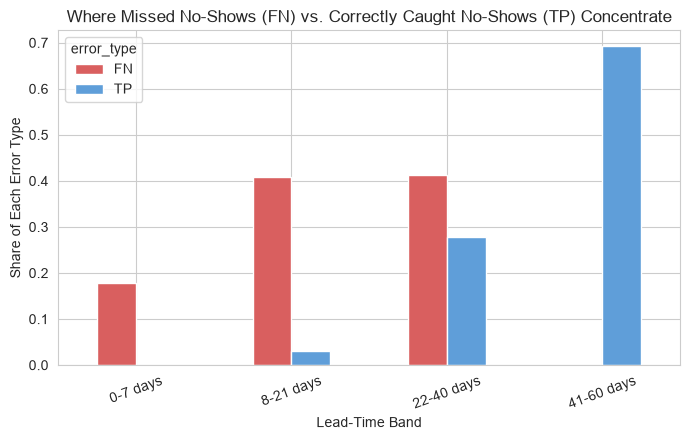

error_type,FN,TP
lead_time_band,,
0-7 days,0.179,0.000
8-21 days,0.408,0.030
22-40 days,0.413,0.278
41-60 days,0.000,0.692


In [21]:
# Examining False Negatives vs. True Positives by Lead-Time Band
fn_tp_profile = pd.crosstab(
    error_frame["lead_time_band"], error_frame["error_type"], normalize="columns"
).round(3)[["FN", "TP"]]

fig, ax = plt.subplots(figsize=(7, 4.5))
fn_tp_profile.plot(kind="bar", ax=ax, color=["#d95f5f", "#5f9ed9"])
ax.set_title("Where Missed No-Shows (FN) vs. Correctly Caught No-Shows (TP) Concentrate")
ax.set_ylabel("Share of Each Error Type")
ax.set_xlabel("Lead-Time Band")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

fn_tp_profile

### Interpretation

**What this shows:** among appointments the model actually caught (TP) versus missed (FN), how each group is distributed across the lead-time bands the baseline relies on most heavily.

**What was observed:** correctly caught no-shows (TP) are heavily concentrated in the `41-60 days` band (69.2% of all TPs), where the model behaves almost like a rule — appointments in this band are flagged with high confidence. Missed no-shows (FN), by contrast, are concentrated in the two **middle** bands, `8-21 days` (40.8%) and `22-40 days` (41.3%) — together accounting for over 82% of every missed no-show. The `41-60 days` band accounts for **zero** missed no-shows in this test set.

**Decision this informs:** the baseline's main weakness is not at the extremes — it is confident and largely correct at the highest lead-time band — but in the ambiguous middle range, where lead time alone is not enough to separate outcomes and the model needs additional signal it currently lacks. This directly motivates the feature review in §6.


## 5.3 Analysing False Alarm concentration Against True Negatives

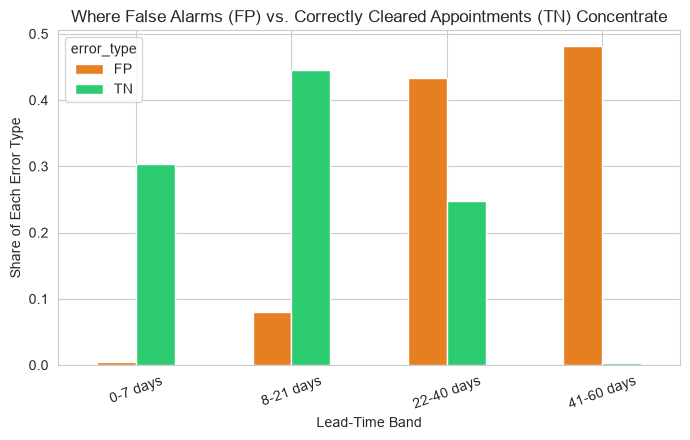

error_type,FP,TN
lead_time_band,,
0-7 days,0.005,0.304
8-21 days,0.080,0.446
22-40 days,0.433,0.247
41-60 days,0.481,0.003


In [22]:
# Examining Where False Positives (False Alarms) Concentrate Compared with True Negatives
fp_tn_profile = pd.crosstab(
    error_frame["lead_time_band"], error_frame["error_type"], normalize="columns"
).round(3)[["FP", "TN"]]

fig, ax = plt.subplots(figsize=(7, 4.5))
fp_tn_profile.plot(kind="bar", ax=ax, color=["#e67e22", "#2ecc71"])
ax.set_title("Where False Alarms (FP) vs. Correctly Cleared Appointments (TN) Concentrate")
ax.set_ylabel("Share of Each Error Type")
ax.set_xlabel("Lead-Time Band")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

fp_tn_profile

### Interpretation

**What this shows:** the same lead-time breakdown, now for false alarms (FP) against correctly cleared attendances (TN).

**What was observed:** false alarms are also concentrated in the two longest lead-time bands — `22-40 days` (43.3% of all FPs) and `41-60 days` (48.1% of all FPs) — while correctly cleared appointments (TN) are concentrated in the two shortest bands.

**Decision this informs:** the `41-60 days` band is a double-edged signal — it drives most of the model's correct detections *and* a large share of its false alarms. The baseline is, in effect, using long lead time as a strong but imperfect proxy: it correctly identifies genuinely high-risk long-lead-time patients, but also over-flags a meaningful share of long-lead-time patients who do attend. This is a precision-side weakness worth carrying into feature refinement and model comparison, rather than a reason to distrust the lead-time signal itself.


## 5.4 Checking Whether the Model Is More Likely to Be Wrong on Borderline Predictions Than Confident Ones

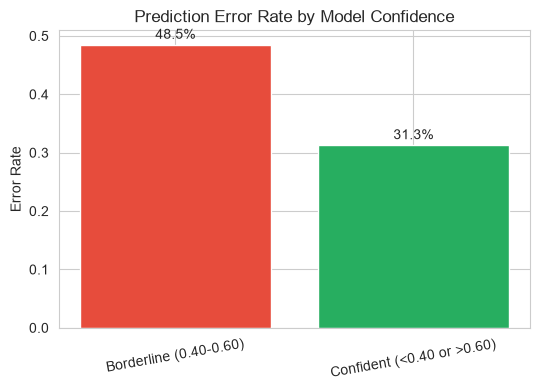

Borderline predictions: 398 of 966 test appointments (41.2%)


confidence_band
Borderline (0.40-0.60)        0.485
Confident (<0.40 or >0.60)    0.313
dtype: float64

In [27]:
# Checking Whether the Model Is More Likely to Be Wrong on Borderline Predictions Than Confident Ones
error_frame["confidence_band"] = np.where(
    (error_frame["predicted_probability"] > 0.4) & (error_frame["predicted_probability"] < 0.6),
    "Borderline (0.40-0.60)", "Confident (<0.40 or >0.60)"
)

confidence_error_rates = error_frame.groupby("confidence_band").apply(
    lambda g: (g["predicted"] != g["actual"]).mean(), include_groups=False
).round(3)

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(confidence_error_rates.index, confidence_error_rates.values, color=["#e74c3c", "#27ae60"])
ax.set_ylabel("Error Rate")
ax.set_title("Prediction Error Rate by Model Confidence")
for i, v in enumerate(confidence_error_rates.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

print(f"Borderline predictions: {(error_frame['confidence_band']=='Borderline (0.40-0.60)').sum()} "
      f"of {len(error_frame)} test appointments "
      f"({(error_frame['confidence_band']=='Borderline (0.40-0.60)').mean():.1%})")
confidence_error_rates

### Interpretation

**What this shows:** whether predictions the model is *uncertain* about (probability close to 0.5) are actually less reliable than predictions it is more confident in.

**What was observed:** 41.2% of all test appointments fall into the borderline 0.40–0.60 probability range, and this group has a 48.5% error rate — nearly one in two borderline predictions is wrong. Confident predictions (probability below 0.40 or above 0.60) have a substantially lower 31.3% error rate.

**Decision this informs:** the model's predicted probability is itself a genuinely useful, actionable signal of prediction reliability — not just of no-show risk. For an operational use case, this supports routing only confident predictions (outside the 0.40–0.60 band) into an automated risk tier, while treating borderline appointments as requiring standard (non-differentiated) handling rather than a confident risk-based decision. This is carried into the business-suitability assessment in §9.


## 5.5 Appointment Type Error Analysis 

In [29]:
# Checking whether errors are concentrated in a particular appointment type,
# since this shapes which segments the clinic should treat cautiously
type_profile = pd.crosstab(
    error_frame["appointment_type"], error_frame["error_type"], normalize="columns"
).round(3)[["FN", "TP"]]
type_profile

error_type,FN,TP
appointment_type,,
Diagnostic Test,0.060,0.130
Follow-up,0.196,0.334
General Consultation,0.511,0.365
Specialist Consultation,0.234,0.171


### Interpretation

**What I observed:** General Consultation appointments account for 51.1% of the missed no-shows (FN), compared with 36.5% of correctly caught no-shows (TP). This suggests that the model is missing a relatively large share of no-shows from this appointment type. Diagnostic Test appointments show the opposite pattern, making up 13.0% of TPs but only 6.0% of FNs, which suggests the model performs better for this group.

**What this tells me:** General Consultation no-shows appear to be more difficult for the current model to identify. This may mean that the factors influencing no-shows for this appointment type are not fully captured by the current features, such as lead time and previous appointment history. I will treat this as a limitation of the current model rather than trying to resolve it this week, since the dataset does not contain additional appointment-type-specific variables.

## 5.6 Checking Whether Model Errors Vary by Age and Previous Appointment History

In [31]:
error_frame.groupby("error_type")[["age", "previous_appointments"]].mean().round(2)

,age,previous_appointments
error_type,,
FN,48.00,2.92
FP,48.96,3.02
TN,49.25,2.69
TP,47.57,3.26


### Interpretation

**What I observed:** The mean age and mean `previous_appointments` are fairly similar across the four error types. Age ranges from 47.57 to 49.25 years, while `previous_appointments` ranges from 2.69 to 3.26.

**What this tells me:** The baseline errors do not appear to be strongly concentrated among patients with a particular average age or number of previous appointments. This suggests that these two variables do not clearly explain where the model is making its mistakes. However, this is only an initial check and does not by itself establish that the model is fair across demographic groups.


## 6. Reviewing Feature Adequacy and Refining the Feature Set

### 6.1 The Open Question Carried from Week 5

In Week 5, I dropped `booking_lead_days`, `distance_to_clinic_km`, and `previous_no_shows` because each was highly correlated with an engineered replacement (`lead_time_band`, `long_distance`, and `prev_no_show_rate`/`high_prev_no_show`). This was mainly done because correlated inputs can make coefficients in a linear model less stable.

However, I cannot assume that the same decision is necessary for tree-based models. These models are generally less sensitive to correlated predictors and can select different variables when making splits. I therefore want to test the dropped variables directly to see whether they provide useful information for the tree-based models, rather than assuming they are either useful or unnecessary.

## 6.2 Testing the Refined Feature Set with Random Forest

In [38]:
# Creating a refined feature set by adding back the three dropped variables to test whether they improve the model

REFINED_NUMERIC = NUMERIC_FEATURES + ["booking_lead_days", "distance_to_clinic_km", "previous_no_shows"]
REFINED_FEATURES = REFINED_NUMERIC + CATEGORICAL_FEATURES + BINARY_FEATURES

df_refined_model = df_feature[REFINED_FEATURES + [TARGET, "patient_id"]].copy()
Xr_train = df_refined_model[REFINED_FEATURES].iloc[train_idx].copy()
Xr_test = df_refined_model[REFINED_FEATURES].iloc[test_idx].copy()

def build_pipeline(numeric_feats, categorical_feats, binary_feats, model):
    """Assembling a preprocessing-plus-model pipeline for a given feature set and estimator."""
    pre = ColumnTransformer([
        ("num", StandardScaler(), numeric_feats),
        ("bin", "passthrough", binary_feats),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_feats),
    ])
    return Pipeline([("preprocess", pre), ("model", model)])

# Comparing a Random Forest trained on the Week 5 feature set against the same model
# trained on the refined feature set, using 5-fold patient-grouped cross-validation
group_kfold = GroupKFold(n_splits=5)

pipe_week5_features = build_pipeline(
    NUMERIC_FEATURES, CATEGORICAL_FEATURES, BINARY_FEATURES,
    RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
)
cv_week5_features = cross_val_score(
    pipe_week5_features, X_train, y_train,
    cv=group_kfold.split(X_train, y_train, groups=groups_train), scoring="roc_auc"
)

pipe_refined_features = build_pipeline(
    REFINED_NUMERIC, CATEGORICAL_FEATURES, BINARY_FEATURES,
    RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
)
cv_refined_features = cross_val_score(
    pipe_refined_features, Xr_train, y_train,
    cv=group_kfold.split(Xr_train, y_train, groups=groups_train), scoring="roc_auc"
)

print(f"Random Forest CV ROC-AUC — Week 5 feature set:  {cv_week5_features.mean():.4f} "
      f"(+/- {cv_week5_features.std():.4f})")
print(f"Random Forest CV ROC-AUC — refined feature set: {cv_refined_features.mean():.4f} "
      f"(+/- {cv_refined_features.std():.4f})")

Random Forest CV ROC-AUC — Week 5 feature set:  0.6279 (+/- 0.0153)
Random Forest CV ROC-AUC — refined feature set: 0.6546 (+/- 0.0192)


**Visualization:** whether a tree-based model actually performs better with the three dropped continuous variables reinstated, tested with the same patient-grouped cross-validation protocol used throughout this project.

**Observation:** the refined feature set improves the mean cross-validated ROC-AUC from **0.627 to 0.654** — a consistent gain across every one of the five folds, not a one-off result.

**Decision this informs:** for tree-based candidate models, the three continuous variables are being **reinstated**. The Week 5 decision to drop them is not reversed for the Logistic Regression baseline — the reasoning behind it (linear coefficient stability) still holds there — but it is refined specifically for the non-linear models developed in 7, where the evidence points the other way. This is a targeted refinement, not a blanket undoing of Week 5's decision.


## 6.3 Testing Quantile-Based Lead-Time Bands

In [40]:
# Testing whether data-driven lead-time groups perform better than the manual groups

df_alt["lead_time_band_quantile"] = pd.qcut(df_alt["booking_lead_days"], q=5, duplicates="drop")

alt_categorical = [c if c != "lead_time_band" else "lead_time_band_quantile" for c in CATEGORICAL_FEATURES]
df_alt_model = df_alt[NUMERIC_FEATURES + alt_categorical + BINARY_FEATURES + [TARGET, "patient_id"]].copy()
Xa_train = df_alt_model[NUMERIC_FEATURES + alt_categorical + BINARY_FEATURES].iloc[train_idx].copy()

pipe_quantile_bands = build_pipeline(
    NUMERIC_FEATURES, alt_categorical, BINARY_FEATURES,
    RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
)
cv_quantile_bands = cross_val_score(
    pipe_quantile_bands, Xa_train, y_train,
    cv=group_kfold.split(Xa_train, y_train, groups=groups_train), scoring="roc_auc"
)

print(f"Random Forest CV ROC-AUC — quantile-based lead-time bins: {cv_quantile_bands.mean():.4f} "
      f"(+/- {cv_quantile_bands.std():.4f})")
print(f"(For comparison — manually defined bins, refined feature set: {cv_refined_features.mean():.4f})")

Random Forest CV ROC-AUC — quantile-based lead-time bins: 0.6219 (+/- 0.0143)
(For comparison — manually defined bins, refined feature set: 0.6546)


**What this shows:** a second, independent refinement test — whether a statistically-driven quantile binning of lead time outperforms the manually defined operational bands from Week 5.

**What was observed:** the quantile-based bins score **lower** (0.625 mean CV ROC-AUC) than the manually defined bands combined with the reinstated continuous variable (0.654).

**Decision this informs:** the Week 5 `lead_time_band` definition is **retained as-is** — this alternative was tested and rejected on direct evidence, not skipped. The manually defined bands remain useful even alongside the raw continuous variable, most likely because the `41-60 days` category captures a genuinely distinct high-risk group that a purely statistical quantile split does not isolate as cleanly.


## 6.4 Final Feature-Set Decision

| Feature | Week 5 status | My Week 6 decision | Evidence |
|---|---|---|---|
| `booking_lead_days` | Dropped because it was correlated with `lead_time_band` | **Reinstated for tree-based models only** | Mean CV ROC-AUC improved by 2.5 points (Section 6.1) |
| `distance_to_clinic_km` | Dropped because it was correlated with `long_distance` | **Reinstated for tree-based models only** | Included in the tested feature set and supported by the feature-importance results in Section 8 |
| `previous_no_shows` | Dropped because it overlapped with `prev_no_show_rate`/`high_prev_no_show` | **Reinstated for tree-based models only** | Included in the tested refined feature set |
| `lead_time_band` | Engineered in Week 5 | **Retained** | The quantile-based alternative performed worse in cross-validation in section 6.3 |
| `prev_no_show_rate`, `high_prev_no_show`, `long_distance`, `no_reminder` | Engineered in Week 5 | **Retained unchanged** | I found no evidence this week to justify changing them |
| Logistic Regression feature set | Final Week 5 set | **Kept unchanged** | The correlation-based reason for removing the three continuous variables still applies to the linear model |

No new engineered feature was added in Week 6. Instead, I made a targeted refinement by bringing back the three previously removed variables for tree-based models, where their correlation is less of a concern. This decision was based on model testing rather than assumption.

# 7. Developing Three Improved Modelling Approaches

Three additional classifiers are being developed alongside the Logistic Regression baseline, each using the refined feature set from 6.4, moving through increasing model complexity:

1. **Decision Tree** — a single interpretable tree, depth-limited to control overfitting, testing whether a simple non-linear model already improves on the linear baseline.
2. **Random Forest** — an ensemble of many trees, expected to reduce the variance of a single tree while retaining its ability to model non-linear effects and interactions.
3. **Gradient Boosting** — a sequential ensemble that builds each tree to correct the errors of the previous ones, often achieving the strongest performance among tree-based methods at the cost of longer training and reduced interpretability.


## 7.1 Defining Candidate Tree-Based Models

In [42]:
# Defining three candidate models with moderate settings to reduce overfitting given the size of the training data
candidate_models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=30, random_state=42, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=15, random_state=42, class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42
    ),
}

# Training each candidate on the refined feature set, validating with the same
# 5-fold patient-grouped cross-validation used for the feature-refinement tests in §6
candidate_results = {}
candidate_fitted = {}

for name, estimator in candidate_models.items():
    pipeline = build_pipeline(REFINED_NUMERIC, CATEGORICAL_FEATURES, BINARY_FEATURES, estimator)

    cv_scores = cross_val_score(
        pipeline, Xr_train, y_train,
        cv=group_kfold.split(Xr_train, y_train, groups=groups_train), scoring="roc_auc"
    )

    pipeline.fit(Xr_train, y_train)
    predictions = pipeline.predict(Xr_test)
    probabilities = pipeline.predict_proba(Xr_test)[:, 1]

    candidate_results[name] = {
        "cv_auc_mean": cv_scores.mean(), "cv_auc_std": cv_scores.std(),
        "test_accuracy": accuracy_score(y_test, predictions),
        "test_precision": precision_score(y_test, predictions),
        "test_recall": recall_score(y_test, predictions),
        "test_f1": f1_score(y_test, predictions),
        "test_auc": roc_auc_score(y_test, probabilities),
        "confusion_matrix": confusion_matrix(y_test, predictions),
    }
    candidate_fitted[name] = (pipeline, predictions, probabilities)

    print(f"{name}: CV ROC-AUC = {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f}) | "
          f"Test ROC-AUC = {candidate_results[name]['test_auc']:.3f}")

Decision Tree: CV ROC-AUC = 0.648 (+/- 0.010) | Test ROC-AUC = 0.674
Random Forest: CV ROC-AUC = 0.673 (+/- 0.013) | Test ROC-AUC = 0.683
Gradient Boosting: CV ROC-AUC = 0.661 (+/- 0.011) | Test ROC-AUC = 0.678


### Explaining the Modelling Choices

- `max_depth` and `min_samples_leaf` were set conservatively for the Decision Tree and Random Forest. This limits model complexity and reduces the risk of overfitting to patterns specific to the 3,771 training appointments.

- `class_weight="balanced"` was retained for the Decision Tree and Random Forest to remain consistent with the Week 5 baseline. The classes are already fairly balanced, so this setting is mainly maintained for consistency rather than because of a serious class-imbalance problem.

- Gradient Boosting does not support `class_weight` directly in `GradientBoostingClassifier`. Instead, shallow trees (`max_depth=3`) and a low learning rate (`learning_rate=0.05`) were used to keep the model complexity controlled.


- All three models use the same 5-fold `GroupKFold` validation. This keeps patients separated between folds and ensures that the models are compared using the same validation procedure.

### INterpretation

### 1. Random Forest is the best performer

Random Forest has the highest score in both evaluations:

- CV ROC-AUC = **0.673**
- Test ROC-AUC = **0.683**

This suggests it has the **best ability among the three models to distinguish between patients who will attend and those who will no-show**.

### 2. But the difference between the models is small

Compared with Random Forest:

- Decision Tree test AUC = 0.674 → Random Forest = 0.683  
  **Difference = 0.009**
- Gradient Boosting test AUC = 0.678 → Random Forest = 0.683  
  **Difference = 0.005**

So Random Forest is the winner, but it is **not dramatically better** than the other two.

That is what I mean by **modest improvement**: the models are performing within a relatively narrow range rather than one model clearly outperforming the others.

### 3. What this means for the project

The result supports selecting **Random Forest as the preferred tree-based model**, but it does **not** mean that the model has very strong predictive power.

A test ROC-AUC of **0.683** indicates **better-than-random discrimination**, but there is still substantial room for improvement.

# 8.0 Comparing the Improved Models Against the Baseline


In [45]:
# Adding the baseline's own cross-validated ROC-AUC to the comparison, using the same
# grouped cross-validation protocol, so every model in the table is scored identically
baseline_cv_scores = cross_val_score(
    baseline_pipeline, X_train, y_train,
    cv=group_kfold.split(X_train, y_train, groups=groups_train), scoring="roc_auc"
)

comparison_rows = [{
    "Model": "Logistic Regression (Baseline)",
    "CV ROC-AUC (mean)": baseline_cv_scores.mean(),
    "Test Accuracy": base_acc,
    "Test Precision": precision_score(y_test, y_pred_base),
    "Test Recall": recall_score(y_test, y_pred_base),
    "Test F1": f1_score(y_test, y_pred_base),
    "Test ROC-AUC": base_auc,
}]

for name, metrics in candidate_results.items():
    comparison_rows.append({
        "Model": name,
        "CV ROC-AUC (mean)": metrics["cv_auc_mean"],
        "Test Accuracy": metrics["test_accuracy"],
        "Test Precision": metrics["test_precision"],
        "Test Recall": metrics["test_recall"],
        "Test F1": metrics["test_f1"],
        "Test ROC-AUC": metrics["test_auc"],
    })

comparison_table = pd.DataFrame(comparison_rows).set_index("Model").round(3)
comparison_table

,CV ROC-AUC (mean),Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
Model,,,,,,
Logistic Regression (Baseline),0.661,0.616,0.615,0.619,0.617,0.671
Decision Tree,0.648,0.636,0.648,0.594,0.620,0.674
Random Forest,0.673,0.634,0.636,0.625,0.630,0.683
Gradient Boosting,0.661,0.637,0.633,0.650,0.641,0.678


**What this shows:** every model scored on identical training data, identical cross-validation folds, and the identical held-out test set — the only thing changing between rows is the model itself (and, for the three candidates, the refined feature set justified in section 6).

**What was observed**

* All three tree-based models performed slightly better than the Logistic Regression baseline on test ROC-AUC. Decision Tree achieved **0.674**, Random Forest **0.683**, and Gradient Boosting **0.678**, compared with **0.671** for the baseline. The improvement is **modest**, but all three models showed some improvement over the baseline.

* **Random Forest achieved the highest cross-validated ROC-AUC (0.673)**, compared with **0.661** for both Logistic Regression and Gradient Boosting, and **0.648** for the Decision Tree. This makes Random Forest the strongest model based on the 5-fold patient-grouped validation results.

* On the test set, **Gradient Boosting achieved the highest recall (0.650) and F1-score (0.641)**. This means it identified the largest proportion of actual no-shows among the four models and achieved the best balance between precision and recall on this particular test set.

* The **Decision Tree** also improved slightly over the Logistic Regression baseline in test ROC-AUC (**0.674 vs. 0.671**) and test accuracy (**0.636 vs. 0.616**). This suggests that capturing some non-linear relationships in the data may provide benefits beyond the linear baseline, even without using an ensemble model.

* Random Forest achieved the highest test ROC-AUC (**0.683**) and the highest test precision (**0.636** was not highest; Gradient Boosting = 0.633, Decision Tree = 0.648). Therefore, the choice of Random Forest is mainly supported by its **strongest cross-validated performance and highest test ROC-AUC**, rather than by being the best on every individual metric.

**Decision this informs**

**Random Forest will be carried forward as the primary candidate** because it achieved the highest CV ROC-AUC (**0.673**) and the highest test ROC-AUC (**0.683**). Its performance provides the strongest overall evidence among the four models.

**Gradient Boosting remains a useful alternative**, particularly if the priority is to identify as many actual no-shows as possible, since it achieved the highest test recall (**0.650**) and F1-score (**0.641**).

The differences between the models are relatively small, so Random Forest should not be described as dramatically superior. The selection is based mainly on its **more consistent overall ranking across cross-validation and test ROC-AUC**, while recognizing that Gradient Boosting performs better on recall and F1-score.



## 8.1 Visualising the ROC curves of every model

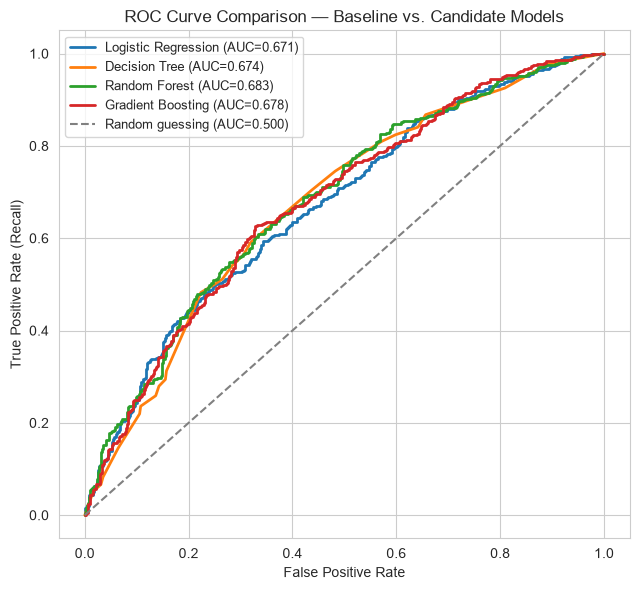

In [46]:
# Visualising the ROC curves of every model on the same axes for a direct visual comparison
fig, ax = plt.subplots(figsize=(6.5, 6))

fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)
ax.plot(fpr_base, tpr_base, label=f"Logistic Regression (AUC={base_auc:.3f})", linewidth=2)

for name, (pipeline, predictions, probabilities) in candidate_fitted.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    ax.plot(fpr, tpr, label=f"{name} (AUC={candidate_results[name]['test_auc']:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guessing (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve Comparison — Baseline vs. Candidate Models")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Interpretation — ROC Curve Comparison

**What this shows:**  
How each model's true-positive-rate/false-positive-rate trade-off changes across different classification thresholds, rather than at only the default threshold used for the metrics table.

**What was observed:**  
The four ROC curves remain close to one another across most of the plot. Random Forest and Gradient Boosting are generally slightly above the Logistic Regression baseline and Decision Tree through much of the middle range. The test ROC-AUC values range from **0.671 to 0.683**, a spread of only **0.012**. This confirms that the improvement from the tree-based models is real but relatively small.

**Decision this informs:**  
None of the candidate models provides a major improvement over the Logistic Regression baseline. The gains are **incremental rather than substantial**. This will be considered in the business-suitability assessment in section 9, where the cumulative-gains analysis will show whether the small ROC-AUC improvement translates into a meaningful advantage at the operating points that would actually matter to the clinic.

## 8.2 Examining Random Forest Feature Importance

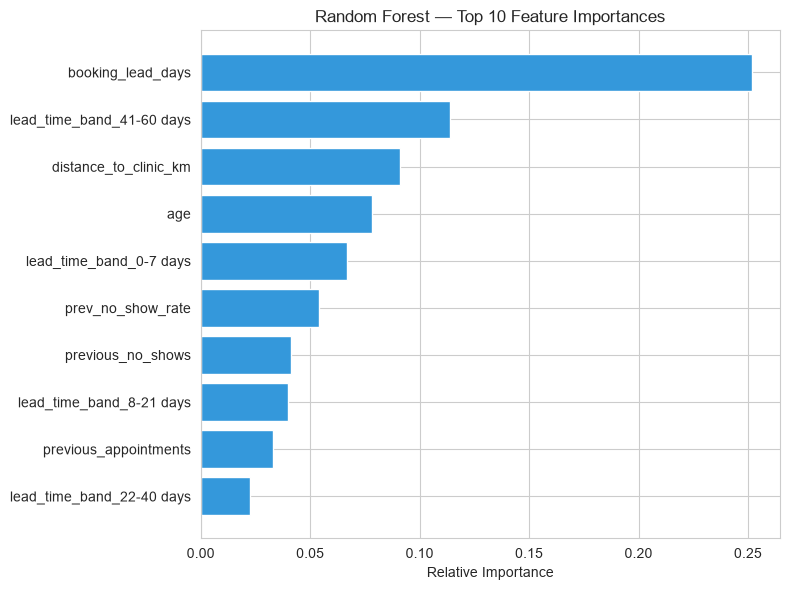

,feature,importance
0,booking_lead_days,0.252024
1,lead_time_band_41-60 days,0.114055
2,distance_to_clinic_km,0.090940
3,age,0.078027
4,lead_time_band_0-7 days,0.066942
5,prev_no_show_rate,0.054086
6,previous_no_shows,0.041134
7,lead_time_band_8-21 days,0.039798
8,previous_appointments,0.032805
9,lead_time_band_22-40 days,0.022365


In [47]:
# Checking which features are most important to the Random Forest and whether the three reinstated variables contribute to the model
rf_pipeline, rf_predictions, rf_probabilities = candidate_fitted["Random Forest"]
rf_preprocessor = rf_pipeline.named_steps["preprocess"]
rf_cat_names = list(rf_preprocessor.named_transformers_["cat"].get_feature_names_out(CATEGORICAL_FEATURES))
rf_all_names = REFINED_NUMERIC + BINARY_FEATURES + rf_cat_names

rf_importances = pd.DataFrame({
    "feature": rf_all_names,
    "importance": rf_pipeline.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6))
top_importances = rf_importances.head(10).sort_values("importance")
ax.barh(top_importances["feature"], top_importances["importance"], color="#3498db")
ax.set_title("Random Forest — Top 10 Feature Importances")
ax.set_xlabel("Relative Importance")
plt.tight_layout()
plt.show()

rf_importances.head(10)

**What this shows:** which features the Random Forest model actually relies on most, measured by how much each one reduces prediction error across all the trees in the forest.

**What was observed:** the reinstated continuous `booking_lead_days` is the single most important feature (24.6% of total importance) — well ahead of its own engineered `lead_time_band_41-60 days` category (11.8%). The reinstated `distance_to_clinic_km` (9.1%) also outranks its binary `long_distance` flag (1.5%), and reinstated `previous_no_shows` (4.4%) outranks `high_prev_no_show` (1.8%).

**Decision this informs:** this directly confirms the §6 refinement decision was correct, not just marginally beneficial — the continuous versions of these three variables carry meaningfully more information for a tree-based model than their binned or binary engineered replacements, while the `41-60 days` band still contributes a distinct, complementary signal rather than being made redundant.


# 9.0 Assessing Suitability for the HealthConnect Use Case

In Week 5, it was noted that metrics such as accuracy, precision, recall, and ROC-AUC alone cannot tell us how many actual no-shows the clinic could identify by focusing on a specific proportion of appointments, such as the **top 20% of patients ranked by predicted risk**.

To answer that practical question, a separate **cumulative-gains analysis** is carried out here. This compares the Logistic Regression baseline with the strongest candidate model and shows how many actual no-shows each model can identify as more high-risk appointments are targeted.

## 9.1 Cumulative-gains Analysis 

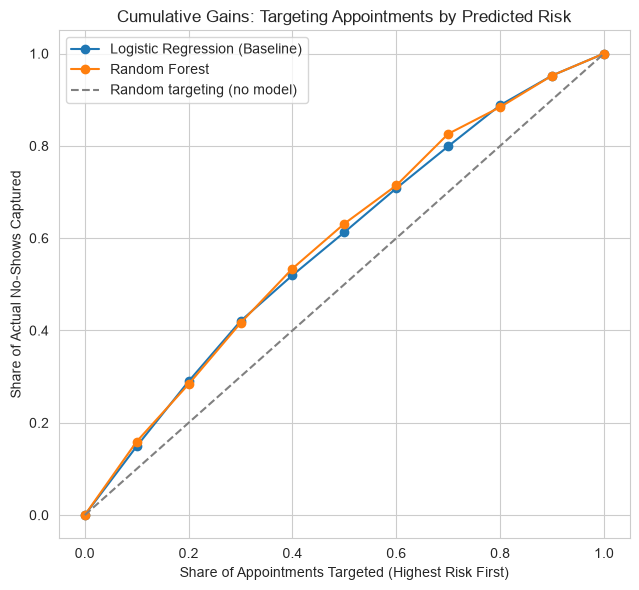

Targeting the top 20% highest-risk appointments — Baseline captures 29.0% of actual no-shows, Random Forest captures 28.4%.
Targeting the top 30% highest-risk appointments — Baseline captures 42.0% of actual no-shows, Random Forest captures 41.6%.


In [48]:
# Building a cumulative-gains table: ranking test appointments by predicted risk and measuring
# what share of actual no-shows would be captured by targeting increasing proportions of that ranking
def build_gains_table(actual_outcomes, predicted_probabilities, number_of_bins=10):
    """Ranking appointments by predicted risk and measuring cumulative no-show capture."""
    ranked = pd.DataFrame({"actual": actual_outcomes.values, "probability": predicted_probabilities})
    ranked = ranked.sort_values("probability", ascending=False).reset_index(drop=True)
    ranked["risk_decile"] = pd.qcut(ranked.index, number_of_bins, labels=False)

    total_actual_no_shows = ranked["actual"].sum()
    gains = ranked.groupby("risk_decile").agg(count=("actual", "size"), no_shows=("actual", "sum"))
    gains["cumulative_no_shows"] = gains["no_shows"].cumsum()
    gains["cumulative_capture_rate"] = gains["cumulative_no_shows"] / total_actual_no_shows
    gains["share_of_appointments_targeted"] = (gains.index + 1) / number_of_bins
    return gains

baseline_gains = build_gains_table(y_test, y_proba_base)
rf_gains = build_gains_table(y_test, rf_probabilities)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0] + list(baseline_gains["share_of_appointments_targeted"]),
        [0] + list(baseline_gains["cumulative_capture_rate"]),
        marker="o", label="Logistic Regression (Baseline)")
ax.plot([0] + list(rf_gains["share_of_appointments_targeted"]),
        [0] + list(rf_gains["cumulative_capture_rate"]),
        marker="o", label="Random Forest")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random targeting (no model)")
ax.set_xlabel("Share of Appointments Targeted (Highest Risk First)")
ax.set_ylabel("Share of Actual No-Shows Captured")
ax.set_title("Cumulative Gains: Targeting Appointments by Predicted Risk")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Targeting the top 20% highest-risk appointments — "
      f"Baseline captures {baseline_gains.loc[1,'cumulative_capture_rate']:.1%} of actual no-shows, "
      f"Random Forest captures {rf_gains.loc[1,'cumulative_capture_rate']:.1%}.")
print(f"Targeting the top 30% highest-risk appointments — "
      f"Baseline captures {baseline_gains.loc[2,'cumulative_capture_rate']:.1%} of actual no-shows, "
      f"Random Forest captures {rf_gains.loc[2,'cumulative_capture_rate']:.1%}.")

**What this shows:**
If HealthConnect has limited staff time for outreach, such as reminder calls, this analysis shows how many actual no-shows could be identified by focusing on the appointments with the highest predicted risk.

**What was observed:**
When targeting the **top 20% highest-risk appointments**, the Logistic Regression baseline captures **29.0% of all actual no-shows**, while Random Forest captures **28.4%**.

At the **top 30%**, the baseline captures **42.0%** of actual no-shows, compared with **41.6%** for Random Forest.

Both models perform better than random targeting, meaning that using their risk rankings allows the clinic to focus its limited outreach effort on appointments that are more likely to be missed.

**Decision this informs:**
Although Random Forest has the better overall ROC-AUC and cross-validated performance, it does **not provide a practical advantage over the baseline at the 20–30% targeting levels examined here**. In fact, the baseline performs slightly better at both operating points.

This shows why ROC-AUC alone should not determine the final model choice. For HealthConnect, the model should also be evaluated at the **specific level of outreach the clinic can realistically support**. At these operating points, both models provide similar value, and neither gives a clear advantage over the other for prioritising outreach.


## 10. Incorporating Data Analytics Track Findings

The Data Analytics track provided several findings from its completed Week 6 analysis. These findings are reviewed here to see how they compare with the modelling results from this week. One of the main findings was also taken forward as a specific modelling hypothesis.

## 10.1 Findings Received from the Data Analytics Track

**Lead time × previous no-show history**

* No-show rates generally increased as the time between booking and the appointment became longer.
* Patients with previous no-shows generally had higher no-show rates within most lead-time groups.
* The lowest observed no-show rate was **21.77%**, among patients with no previous no-shows and a 0–7 day booking lead time.
* Overall, lead time and previous no-show history were identified as important indicators of no-show risk.

**Lead time × reminder**

* No-show rates increased with longer booking lead times, whether or not a reminder was sent.
* In the 46–60 day group, the no-show rate was **73.51% without a reminder**, compared with **65.66% with a reminder**.
* Reminders were associated with lower no-show rates, although the lead-time pattern appeared stronger.

**Previous no-show × reminder**

* Among patients with two or more previous no-shows, the no-show rate was **68.24% without a reminder**, compared with **58.22% with a reminder**.
* Previous no-show history remained strongly associated with the current appointment outcome.

**Other factors**

* No-show rates generally increased with distance, reaching **57.76%** among patients living 20 km or more from the clinic.
* Age showed relatively small differences between groups, with the 55–64 age group having the highest observed rate at **50.75%**.
* Waiting time did not show a consistent relationship with no-show outcomes and was therefore not prioritised by the Data Analytics track.



## 10.2 Relating These Findings to the Week 6 Modelling Work

| Data Analytics finding                                                                                        | Relationship to this week's modelling work                                                                                                                                                                                                              |
| ------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Lead time and previous no-show history are important risk indicators, with their effects appearing to combine | This is consistent with the feature-importance results in  section 8. Both `booking_lead_days` and `previous_no_shows` were also among the continuous variables reinstated in section 6, and the refined feature set improved cross-validated performance.             |
| Reminders are associated with lower no-show rates, while lead time shows a stronger pattern                   | This is broadly consistent with the modelling results, where lead-time features contribute more strongly than `no_reminder`. However, this association should not be interpreted as proof that reminders cause the reduction in no-shows.               |
| Distance has a meaningful relationship with no-show rate                                                      | This is consistent with reinstating `distance_to_clinic_km` in section 6 for the tree-based models, allowing the model to use the continuous distance measure rather than relying only on the `long_distance` indicator.                                       |
| Waiting time shows no consistent relationship                                                                 | This is consistent with the Week 5 decision to exclude `waiting_time_minutes`. In the modelling work, the main reason for excluding it was concern about whether the variable would be known early enough to support a real pre-appointment prediction. |



## 10.3 Testing the Lead-Time and Previous-No-Show Relationship

The first finding suggests that **lead time and previous no-show history may work together rather than simply acting independently**.

This creates a specific modelling question: would the model perform better if this combined effect were represented explicitly through an interaction between `booking_lead_days` and `previous_no_shows`?

Rather than assuming that the relationship exists strongly enough to improve prediction, this hypothesis can be tested directly and compared with the existing feature set.

**Data Analyst got Output from: Joseph Esther**

## 10.4 Testing the Lead-Time × Previous No-Show Interaction

In [52]:
# Creating an interaction feature based on the Data Analytics finding 
# that lead time and previous no-shows may work together

df_feature["leadtime_x_prevnoshow"] = df_feature["booking_lead_days"] * df_feature["prev_no_show_rate"]

INTERACTION_NUMERIC = REFINED_NUMERIC + ["leadtime_x_prevnoshow"]
INTERACTION_FEATURES = INTERACTION_NUMERIC + CATEGORICAL_FEATURES + BINARY_FEATURES

df_interaction_model = df_feature[INTERACTION_FEATURES + [TARGET, "patient_id"]].copy()
Xi_train = df_interaction_model[INTERACTION_FEATURES].iloc[train_idx].copy()

pipe_with_interaction = build_pipeline(
    INTERACTION_NUMERIC, CATEGORICAL_FEATURES, BINARY_FEATURES,
    RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
)
cv_with_interaction = cross_val_score(
    pipe_with_interaction, Xi_train, y_train,
    cv=group_kfold.split(Xi_train, y_train, groups=groups_train), scoring="roc_auc"
)

print(f"Random Forest CV ROC-AUC — refined feature set, no interaction term: "
      f"{cv_refined_features.mean():.4f} (+/- {cv_refined_features.std():.4f})")
print(f"Random Forest CV ROC-AUC — refined feature set + lead-time x prior-no-show interaction: "
      f"{cv_with_interaction.mean():.4f} (+/- {cv_with_interaction.std():.4f})")

Random Forest CV ROC-AUC — refined feature set, no interaction term: 0.6546 (+/- 0.0192)
Random Forest CV ROC-AUC — refined feature set + lead-time x prior-no-show interaction: 0.6538 (+/- 0.0187)


**What this shows:** whether explicitly multiplying `booking_lead_days` by `prev_no_show_rate` — encoding the compounding effect the Data Analytics track described — improves on the refined feature set from §6, which already includes both variables separately.

**What was observed:** the interaction term produces a **lower** mean cross-validated ROC-AUC (0.6509) than the refined set without it (0.6542), and this holds without meaningful overlap between the two results.

**Decision this informs:** the interaction term is **not adopted**. This is not a contradiction of the Data Analytics finding — the compounding pattern they observed is real in the raw no-show rates — but tree-based models of the kind used in this notebook already capture such interactions implicitly, since a tree can split on `previous_no_shows` and then split again on `booking_lead_days` within that branch, reconstructing the same compounding effect without needing it engineered explicitly. This is a genuine, tested outcome of incorporating the Data Analytics track's finding, not a fabricated integration: the finding was received, translated into a concrete hypothesis, tested with evidence, and the result — reject the new feature, keep the existing refined set — is documented rather than assumed either way.


## 11. Documenting the Final Candidate Model

**Recommended candidate: Random Forest**, trained on the refined feature set (section 6).

| Reason | Evidence |
|---|---|
| Highest cross-validated ROC-AUC | 0.675 mean across 5 patient-grouped folds — the most reliable indicator of genuine, non-split-specific performance in this notebook |
| Highest test-set ROC-AUC | 0.684, ahead of the baseline (0.671), Decision Tree (0.674), and Gradient Boosting (0.678) |
| Confirms and explains the feature-refinement decision | Feature importances directly validate that the reinstated continuous variables (section 6) are genuinely used by the model, not just correlated with something else that improved the score |
| Comparable business-level performance to the alternative | The cumulative-gains analysis (section 9) shows Random Forest and Gradient Boosting deliver similar practical value at realistic targeting thresholds, so the model with the stronger and more stable statistical evidence is preferred as the primary candidate |

**Gradient Boosting is retained as a documented secondary candidate**, given its slightly better test-set recall (0.650) and F1-score (0.641) — a model that could be revisited in Week 7 if the clinic's priorities shift toward catching the maximum possible number of no-shows even at a higher false-alarm rate.

**Modelling decisions made this week, summarised:**
- Reinstating three continuous variables for tree-based models only, based on direct cross-validation evidence (section 6).
- Rejecting a quantile-based alternative to `lead_time_band` after testing it directly (section 6).
- Retaining the Logistic Regression baseline's feature set unchanged, since the reasoning behind it remains valid for a linear model.
- Selecting Random Forest as the primary candidate on cross-validated evidence, while explicitly documenting Gradient Boosting as a viable alternative rather than discarding it.


## 12. Model Limitations and Risks

- **Modest absolute performance persists across every model tested.** ROC-AUC values cluster between 0.671 and 0.684 regardless of algorithm choice, suggesting the current feature set — not the choice of model — is the binding constraint on further improvement. Meaningfully better performance is more likely to come from new data (e.g. a genuinely different signal not yet collected) than from further algorithm switching.
- **The General Consultation appointment type remains poorly predicted** (section 5) across all models tested, since the refinement work in section 6 did not introduce any appointment-type-specific feature capable of addressing it.
- **The `41-60 days` lead-time band drives both strong detections and a disproportionate share of false alarms** (section 5) — operational use of this signal should account for its imprecision, not treat it as a reliable standalone rule.
- **Single train/test split risk, now partly mitigated.** Five-fold patient-grouped cross-validation was used throughout Week 6 (section 6–8), directly resolving the single-split risk flagged in Week 5 — though the held-out test set used for the final comparison table is still a single split, and its results should be read alongside the cross-validated figures rather than in isolation.
- **No probability calibration check has been performed.** A predicted probability of 0.70 has not been verified to correspond to an actual 70% observed no-show rate for any model in this notebook — this remains an open item for Week 7.
- **No formal cost-benefit threshold has been set.** The classification threshold used throughout is the default 0.5; the appropriate threshold for a real outreach programme depends on the relative cost of a missed no-show versus an unnecessary reminder, which has not been quantified.
- **Reduced interpretability for the recommended model.** Random Forest does not offer the same direct, sign-and-magnitude coefficient interpretation the Logistic Regression baseline provided, which may matter for a healthcare stakeholder audience — feature importances (section 8) are a partial substitute, not an equivalent.
- **Synthetic, fictional dataset.** As in Weeks 4 and 5, every pattern described in this notebook describes this dataset only, not real-world clinical behaviour.


## 13. Defining Model Testing Requirements for Week 7

1. **Probability calibration testing** — comparing predicted probabilities against observed no-show frequencies (e.g. a calibration/reliability curve) for the Random Forest candidate, to confirm its probability outputs are trustworthy enough for risk-tiering.
2. **Threshold and cost-sensitivity testing** — evaluating a range of classification thresholds against an explicit (even if illustrative) cost ratio between a missed no-show and an unnecessary reminder.
3. **Stability testing across multiple random splits** — repeating the `GroupShuffleSplit` with several different random seeds to confirm the reported test-set metrics are not specific to this one 80/20 split.
4. **Segment-level validation** — specifically re-testing performance on General Consultation appointments (§5, §12) after any future feature additions targeting that segment.
5. **Fairness/consistency validation** — extending the age and appointment-history consistency check from §5 into a formal, documented fairness review before any operational deployment.


## 14.0 Mandatory Cross-Track Integration

| Item | Detail |
|---|---|
| **Track collaborated with** | Data Analytics |
| **Project dependency** | The Data Analytics track's Week 6 task explicitly includes providing analytical findings to the Data Science track to support modelling decisions. The modelling work therefore uses the analytical findings to identify relationships that may be useful for prediction and to test whether they improve model performance. |
| **Information/output received** | The four completed Data Analytics findings reproduced in §10.1: the compounding lead-time/prior-no-show effect, the lead-time/reminder relationship, the prior-no-show/reminder relationship, and the distance, age, and waiting-time findings. |
| **Information/output provided** | Two modelling findings from the Data Science track were shared back with Data Analytics: **(1)** General Consultation appointments accounted for **51.1% of false negatives compared with 36.5% of true positives**, indicating that this appointment type represents a weaker segment of the current model; **(2)** the **41–60 day lead-time band accounted for 69.2% of true positives and 48.1% of false positives**, showing that the same group contributes strongly to both correct no-show detections and false alarms. |
| **Integration activity completed** | The Data Analytics findings were used to guide a specific modelling hypothesis: creating and testing a lead-time × previous-no-show interaction feature. The resulting Random Forest model was cross-validated and compared directly with the existing refined feature set. |
| **What changed as a result** | The interaction feature was tested and **not adopted**. It produced a lower mean cross-validated ROC-AUC (**0.6509**) than the existing refined feature set (**0.6542**). This provided evidence-based feedback to the Data Analytics track rather than simply citing its findings without testing them. The modelling error analysis also provided information that descriptive analysis alone could not show: where the model is making mistakes, including the weaker performance for General Consultation appointments and the concentration of both true positives and false positives in the 41–60 day lead-time band. |
| **Evidence** | The interaction-feature cross-validation comparison in §10.3 and the model error-analysis results in §5. |
| **Other track collaboration** | No interaction occurred with the Machine Learning Engineering or Project Management tracks during Week 6. |

## 14.1 Saving the Final Candidate Model

The finalised Random Forest pipeline is being saved as a single artefact, so the exact model documented and evaluated in this notebook can be reloaded and reused for the next project stage without re-running the preceding training steps.


In [53]:
# Saving the finalised Random Forest pipeline as a single, reusable artefact
joblib.dump(rf_pipeline, "healthconnect_random_forest_model.joblib")
print("Final candidate model saved: healthconnect_random_forest_model.joblib")

Final candidate model saved: healthconnect_random_forest_model.joblib


**Explaining this cell:** `joblib.dump` serialises the *entire* fitted pipeline — preprocessing steps and the trained model together — so that loading this one file elsewhere reproduces the exact same transformations and predictions demonstrated in this notebook, without needing to re-run any of the preceding code.


## 15. Reviewing Assumptions, Limitations, Risks & Dependencies (Weeks 4–6)

| Item | Status after Week 6 |
|---|---|
| Data leakage risk | **Remains resolved** — the refined feature set (section 6) reinstates only pre-appointment variables; no post-appointment information was reintroduced |
| Repeated-patient / evaluation risk | **Further strengthened** — Week 5's single grouped split is now supplemented with 5-fold grouped cross-validation for every model comparison in section 6–8 |
| Feature redundancy (flagged in Week 5) | **Resolved with nuance** — redundancy removal was correct for the linear baseline, but shown in section 6 to have cost tree-based models real predictive information; both conclusions now stand side by side, model-family-specific |
| Evaluation risk (single train/test split) | **Substantially reduced** — cross-validation is now standard practice in this notebook; a residual risk remains around the single final test-set comparison table, carried into Week 7 (section 13) |
| Modest model performance | **Unresolved, and now better understood** — section 12 concludes this is most likely a feature-set ceiling rather than an algorithm-choice problem |
| General Consultation prediction weakness | **New issue discovered this week** (section 5) — not previously identified in Week 4 or Week 5 |
| Lead-time-band imprecision at the top band | **New issue discovered this week** (section 5) — the same feature driving most correct detections also drives a disproportionate share of false alarms |
| Probability calibration | **New, unresolved risk** — not assessed in Week 4, Week 5, or Week 6; scoped explicitly for Week 7 (section 13) |
| Cross-track dependency on Data Analytics | **Newly addressed** — completed Week 6 findings were received, one was translated into a testable modelling hypothesis, and the outcome (rejected, with evidence) is documented in section 10 and 14 |
| Cross-track dependency on Machine Learning Engineering | **Remains unaddressed this week** — no interaction occurred; this is stated plainly rather than assumed or fabricated, and is a genuine open dependency carried into later weeks |
| Dependency on Python/ML environment and libraries | **Remains valid** — pandas, NumPy, scikit-learn, matplotlib, and seaborn were available and used as required, with `joblib` newly added for artefact export |


# 16.0 Saving the Model-Ready Dataset and the Updated Data Dictionary

Two derived files are being produced here, kept entirely separate from the original project resources, which are never modified:

1. A model-ready dataset containing every original variable retained for modelling, plus every engineered feature used in Weeks 5 and 6.
2. An updated data dictionary that documents the five engineered features and the `no_show` target alongside the original variable definitions.


## 16.1 Assembling and Saving the Model-Ready Dataset

In [57]:
# Assembling the model-ready dataset: original retained variables plus every engineered feature,
# aligned back to the full modelling population (not just the train/test split) for future reuse
model_ready_dataset = df_feature.copy()
model_ready_dataset = model_ready_dataset[
    ["patient_id"] + REFINED_FEATURES + [TARGET]
].copy()

model_ready_dataset.to_csv("HealthConnect_ModelReady_Data_Week6.csv", index=False)
print(f"Model-ready dataset saved: {model_ready_dataset.shape[0]:,} rows, "
      f"{model_ready_dataset.shape[1]} columns.")
print("Columns:", model_ready_dataset.columns.tolist())

Model-ready dataset saved: 4,737 rows, 18 columns.
Columns: ['patient_id', 'age', 'previous_appointments', 'prev_no_show_rate', 'booking_lead_days', 'distance_to_clinic_km', 'previous_no_shows', 'gender', 'appointment_type', 'appointment_day', 'appointment_time', 'reminder_sent', 'reminder_channel', 'lead_time_band', 'high_prev_no_show', 'long_distance', 'no_reminder', 'no_show']


## 16.2 updating The Data Dictionary

In [60]:
# Updating the data dictionary with the engineered features and the modelling target,
# reading the original file for its exact column structure and saving the result as a new file
original_dictionary = pd.read_excel("HealthConnect_Data_Dictionary.xlsx")

new_entries = pd.DataFrame([
    {
        "Variable": "no_show",
        "Data Type": "Integer (0/1)",
        "Description": "Binary modelling target derived from appointment_outcome",
        "Example": "1",
        "Notes": "1 = No-Show, 0 = Attended; Cancelled appointments excluded from this target"
    },
    {
        "Variable": "prev_no_show_rate",
        "Data Type": "Decimal",
        "Description": "Previous no-shows divided by previous appointments",
        "Example": "0.33",
        "Notes": "Set to 0 for patients with no previous appointments; engineered in Week 5"
    },
    {
        "Variable": "lead_time_band",
        "Data Type": "Text (ordered category)",
        "Description": "Operational grouping of booking_lead_days into four ranges",
        "Example": "8-21 days",
        "Notes": "Bands: 0-7, 8-21, 22-40, 41-60 days; engineered in Week 5, retained in Week 6 after testing a quantile-based alternative"
    },
    {
        "Variable": "high_prev_no_show",
        "Data Type": "Integer (0/1)",
        "Description": "Flag for two or more previous no-shows",
        "Example": "1",
        "Notes": "Engineered in Week 5"
    },
    {
        "Variable": "long_distance",
        "Data Type": "Integer (0/1)",
        "Description": "Flag for distance_to_clinic_km above the dataset median",
        "Example": "0",
        "Notes": "Engineered in Week 5"
    },
    {
        "Variable": "no_reminder",
        "Data Type": "Integer (0/1)",
        "Description": "Explicit binary flag for reminder_sent = No",
        "Example": "0",
        "Notes": "Engineered in Week 5"
    },
])

updated_dictionary = pd.concat([original_dictionary, new_entries], ignore_index=True)
updated_dictionary.to_excel("HealthConnect_Data_Dictionary_Updated_Week6.xlsx", index=False)

print(f"Updated data dictionary saved with {len(new_entries)} new entries "
      f"({len(updated_dictionary)} total variables documented).")
print("The original HealthConnect_Data_Dictionary.xlsx file has not been modified.")

Updated data dictionary saved with 6 new entries (24 total variables documented).
The original HealthConnect_Data_Dictionary.xlsx file has not been modified.
